<a href="https://colab.research.google.com/github/fernandinhaalmeida84/Tech_Challenge_Fase_2/blob/main/Notebook/01_EAD_An%C3%A1lise_Explorat%C3%B3ria_dos_Dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Análise Exporatória dos dados**
Iniciamos importando as bibliotecas que utilizaremos para explorarmos o que tem nos arquivos bases, para entendermos o que tem em cada coluna.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

In [16]:
df_excel = pd.read_csv("application_record.csv", sep=",")

In [17]:
df_excel.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0




##**1.1 Examinando a estrutura do arquivo "Application_record.csv"**

O arquivo possui 18 colunas e 438557 linhas.

Para melhor entendimento, colocamos o significado em português das colunas:

---


 - ID – Código do cliente
 - CODE_GENDER - Gênero
 - FLAG_OWN_CAR - Possui carro
 - FLAG_OWN_REALTY – Possui imóvel próprio
 - CNT_CHILDREN - Qtd de filhos
 - AMT_INCOME_TOTAL - Renda total declarada
 - NAME_INCOME_TYPE - Tipo/fonte de renda
 - NAME_EDUCATION_TYPE – Nível de escolaridade
 - NAME_FAMILY_STATUS - Estado civil
 - NAME_HOUSING_TYPE - Tipo de moradia
 - DAYS_BIRTH – Idade em dias
 - DAYS_EMPLOYED – Tempo de serviço em dias
 - FLAG_MOBIL - Possui celular
 - FLAG_WORK_PHONE - Telefone do trabalho
 - FLAG_PHONE  - Telefone cadastrado
 - FLAG_EMAIL- E-mail cadastrado
 - OCCUPATION_TYPE – Profissão/ocupação
 - CNT_FAM_MEMBERS – Qtd de pessoas no núcleo familiar


In [18]:
df_excel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

In [19]:
df_excel.shape

(438557, 18)

In [20]:
df_excel['ID'].nunique()

438510

In [21]:
df_excel.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,4.385570e+05,438557.000000,4.385570e+05,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,438557.000000
mean,6.022176e+06,0.427390,1.875243e+05,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,2.194465
std,5.716370e+05,0.724882,1.100869e+05,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,0.897207
min,5.008804e+06,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.609375e+06,0.000000,1.215000e+05,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,6.047745e+06,0.000000,1.607805e+05,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,6.456971e+06,1.000000,2.250000e+05,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,3.000000
max,7.999952e+06,19.000000,6.750000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000


**Valores nulos**

Em OCCUPATION_TYPE encontramos 134203 valores nulos e realizamos o tratamento, onde alteramos os nulos desta coluna por "Unknow".

In [22]:
df_excel.isnull().sum()

,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0


In [23]:
df_excel['OCCUPATION_TYPE'] = df_excel['OCCUPATION_TYPE'].fillna('Unknown')

In [24]:
df_excel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

**Limpeza e tratamento dos dados**

As colunas DAYS_BIRTH e DAYS_EMPLOYED estão com os dados em dias e com valores negativos.

Tratamos a coluna DAYS_BIRTH com a criação de nova coluna "Idade", onde o valor foi alterado para positivo e anos, considerando o ano bissexto.

Na coluna DAYS_EMPLOYED, varificamos que o valor positivo "365243" é uma nomalia na base de dados que costuma representar pessoas que estão atualmente desempregadas ou aposentadas, visto que os dias de trabalho ativos são registrados como números negativos. Tratamos com a criação de nova coluna chamada "Desempregados ou aposentados", se o valor for exatamente "365243", a nova coluna receberá "True".

Como tratamento, através da coluna DAYS_EMPLOYED, criamos nova coluna chamada "Anos_Trabalhados" que mostra quantos anos cada pessoa tem de serviço, tratando o valor positivo 365243 igual a 0 anos

In [25]:
df_excel['Idade'] = (df_excel['DAYS_BIRTH'] * -1) / 365.25

In [26]:
df_excel['Desempregado ou aposentado'] = df_excel['DAYS_EMPLOYED'] == 365243

In [27]:
df_excel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   ID                          438557 non-null  int64  
 1   CODE_GENDER                 438557 non-null  object 
 2   FLAG_OWN_CAR                438557 non-null  object 
 3   FLAG_OWN_REALTY             438557 non-null  object 
 4   CNT_CHILDREN                438557 non-null  int64  
 5   AMT_INCOME_TOTAL            438557 non-null  float64
 6   NAME_INCOME_TYPE            438557 non-null  object 
 7   NAME_EDUCATION_TYPE         438557 non-null  object 
 8   NAME_FAMILY_STATUS          438557 non-null  object 
 9   NAME_HOUSING_TYPE           438557 non-null  object 
 10  DAYS_BIRTH                  438557 non-null  int64  
 11  DAYS_EMPLOYED               438557 non-null  int64  
 12  FLAG_MOBIL                  438557 non-null  int64  
 13  FLAG_WORK_PHON

In [28]:
df_excel['Anos_Trabalhados'] = df_excel['DAYS_EMPLOYED'].apply(lambda x: 0.0 if x == 365243 else (x * -1) / 365.25)

**Dados duplicados**

Tratamento de dados duplicados com remoção das linhas onde o ID cosntava duplicado.

In [29]:
df_excel.drop_duplicates()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,Idade,Desempregado ou aposentado,Anos_Trabalhados
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,Unknown,2.0,32.867899,False,12.435318
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,Unknown,2.0,32.867899,False,12.435318
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,-1134,1,0,0,0,Security staff,2.0,58.792608,False,3.104723
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,-3051,1,0,1,1,Sales staff,1.0,52.320329,False,8.353183
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,-3051,1,0,1,1,Sales staff,1.0,52.320329,False,8.353183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438552,6840104,M,N,Y,0,135000.0,Pensioner,Secondary / secondary special,Separated,House / apartment,...,365243,1,0,0,0,Unknown,1.0,62.195756,True,0.000000
438553,6840222,F,N,N,0,103500.0,Working,Secondary / secondary special,Single / not married,House / apartment,...,-3007,1,0,0,0,Laborers,1.0,43.638604,False,8.232717
438554,6841878,F,N,N,0,54000.0,Commercial associate,Higher education,Single / not married,With parents,...,-372,1,1,0,0,Sales staff,1.0,22.365503,False,1.018480
438555,6842765,F,N,Y,0,72000.0,Pensioner,Secondary / secondary special,Married,House / apartment,...,365243,1,0,0,0,Unknown,2.0,59.337440,True,0.000000


In [30]:
df_excel.duplicated(subset=['ID']).sum()

np.int64(47)

In [31]:
ids_duplicados = df_excel[df_excel.duplicated(subset=['ID'], keep=False)]

In [32]:
df_excel.drop_duplicates(subset=['ID'], keep='first', inplace=True)

In [33]:
print(f"Quantidade de IDs duplicados após a remoção: {df_excel.duplicated(subset=['ID']).sum()}")

Quantidade de IDs duplicados após a remoção: 0


In [34]:
df_excel.info()

<class 'pandas.core.frame.DataFrame'>
Index: 438510 entries, 0 to 438556
Data columns (total 21 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   ID                          438510 non-null  int64  
 1   CODE_GENDER                 438510 non-null  object 
 2   FLAG_OWN_CAR                438510 non-null  object 
 3   FLAG_OWN_REALTY             438510 non-null  object 
 4   CNT_CHILDREN                438510 non-null  int64  
 5   AMT_INCOME_TOTAL            438510 non-null  float64
 6   NAME_INCOME_TYPE            438510 non-null  object 
 7   NAME_EDUCATION_TYPE         438510 non-null  object 
 8   NAME_FAMILY_STATUS          438510 non-null  object 
 9   NAME_HOUSING_TYPE           438510 non-null  object 
 10  DAYS_BIRTH                  438510 non-null  int64  
 11  DAYS_EMPLOYED               438510 non-null  int64  
 12  FLAG_MOBIL                  438510 non-null  int64  
 13  FLAG_WORK_PHONE    

In [35]:
display(df_excel[['ID', 'OCCUPATION_TYPE', 'Idade', 'Desempregado ou aposentado', 'Anos_Trabalhados']].head())

,ID,OCCUPATION_TYPE,Idade,Desempregado ou aposentado,Anos_Trabalhados
0,5008804,Unknown,32.867899,False,12.435318
1,5008805,Unknown,32.867899,False,12.435318
2,5008806,Security staff,58.792608,False,3.104723
3,5008808,Sales staff,52.320329,False,8.353183
4,5008809,Sales staff,52.320329,False,8.353183


**Identificação de outliers**

Analisamos cada variável numérica relevante para entender o comportamento de seus outliers por meio de métricas estatísticas e visualizações gráficas (Boxplot e Histograma).

*   Análise da Renda Total






--- AMT_INCOME_TOTAL ---
Limite superior para outlier: R$ 380,250.00
Quantidade de registros acima do limite: 19106 (4.36%)
Maior renda registrada: R$ 6,750,000.00


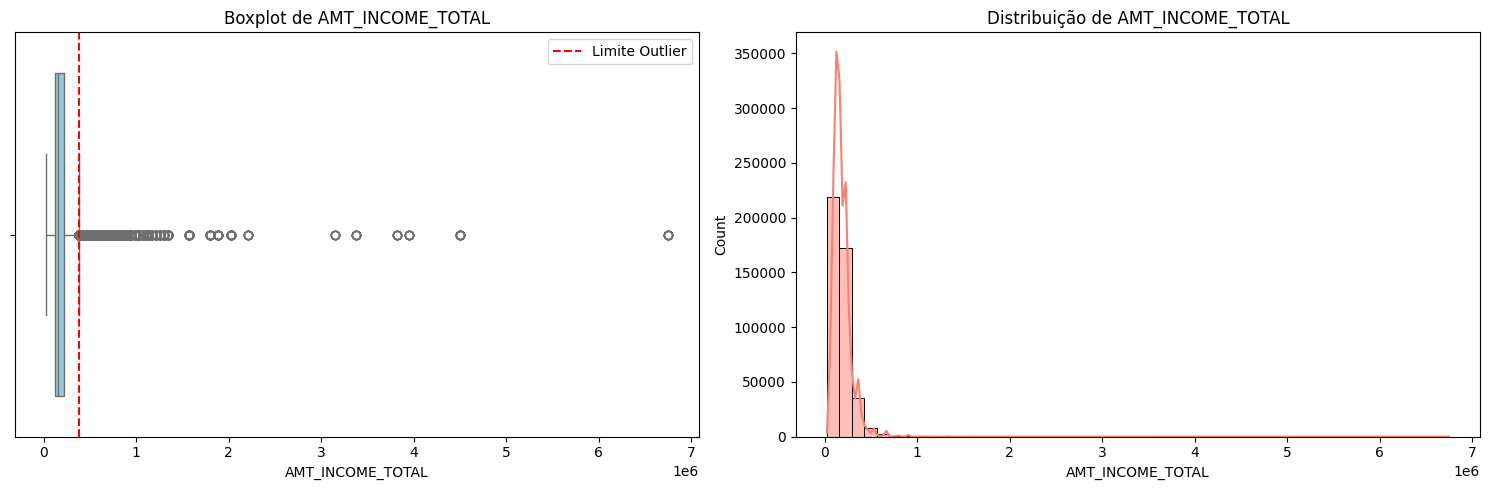

In [36]:
col = 'AMT_INCOME_TOTAL'
Q1 = df_excel[col].quantile(0.25)
Q3 = df_excel[col].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

outliers = df_excel[df_excel[col] > limite_superior]
print(f"--- {col} ---")
print(f"Limite superior para outlier: R$ {limite_superior:,.2f}")
print(f"Quantidade de registros acima do limite: {outliers.shape[0]} ({outliers.shape[0]/df_excel.shape[0]*100:.2f}%)")
print(f"Maior renda registrada: R$ {df_excel[col].max():,.2f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(ax=axes[0], x=df_excel[col], color='skyblue')
axes[0].set_title(f'Boxplot de {col}')
axes[0].axvline(limite_superior, color='red', linestyle='--', label='Limite Outlier')
axes[0].legend()

sns.histplot(ax=axes[1], x=df_excel[col], bins=50, kde=True, color='salmon')
axes[1].set_title(f'Distribuição de {col}')
plt.tight_layout()
plt.show()

Tratamento dos outliers da Renda Total

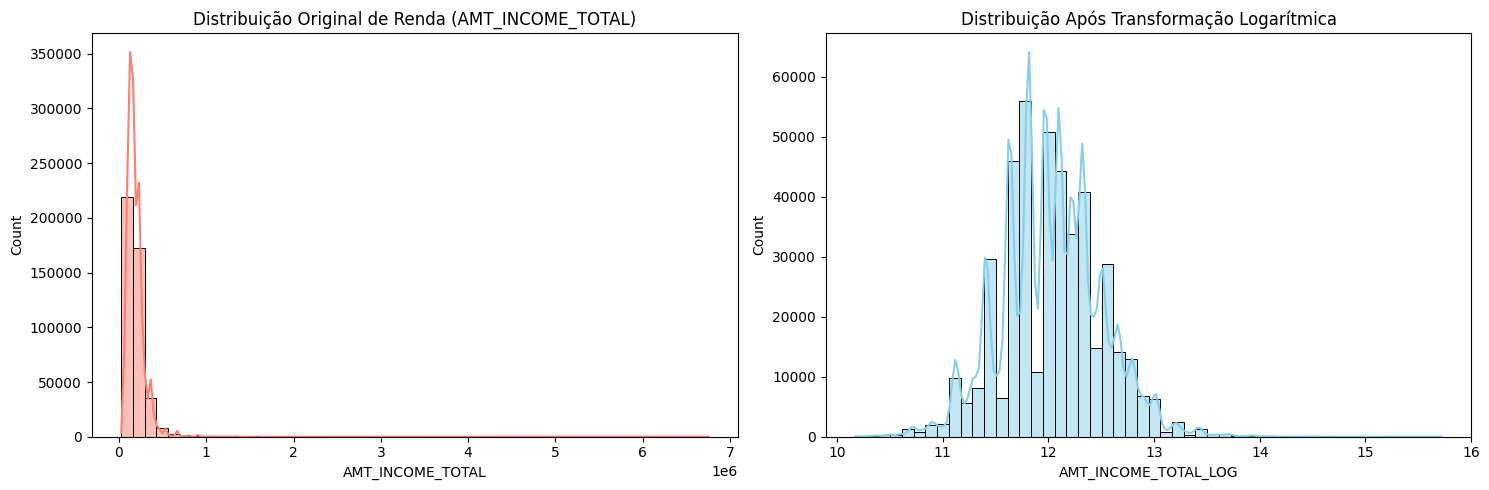

In [37]:
df_excel['AMT_INCOME_TOTAL_LOG'] = np.log1p(df_excel['AMT_INCOME_TOTAL'])
if 'df' in globals():
    df['AMT_INCOME_TOTAL_LOG'] = np.log1p(df['AMT_INCOME_TOTAL'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(ax=axes[0], x=df_excel['AMT_INCOME_TOTAL'], bins=50, kde=True, color='salmon')
axes[0].set_title('Distribuição Original de Renda (AMT_INCOME_TOTAL)')

sns.histplot(ax=axes[1], x=df_excel['AMT_INCOME_TOTAL_LOG'], bins=50, kde=True, color='skyblue')
axes[1].set_title('Distribuição Após Transformação Logarítmica')

plt.tight_layout()
plt.show()

*   Análise do tempo de serviço

--- Anos_Trabalhados ---
Limite superior para outlier: 19.72 anos
Quantidade de registros acima do limite: 21970 (5.01%)
Máximo de anos trabalhados registrado: 48.00 anos


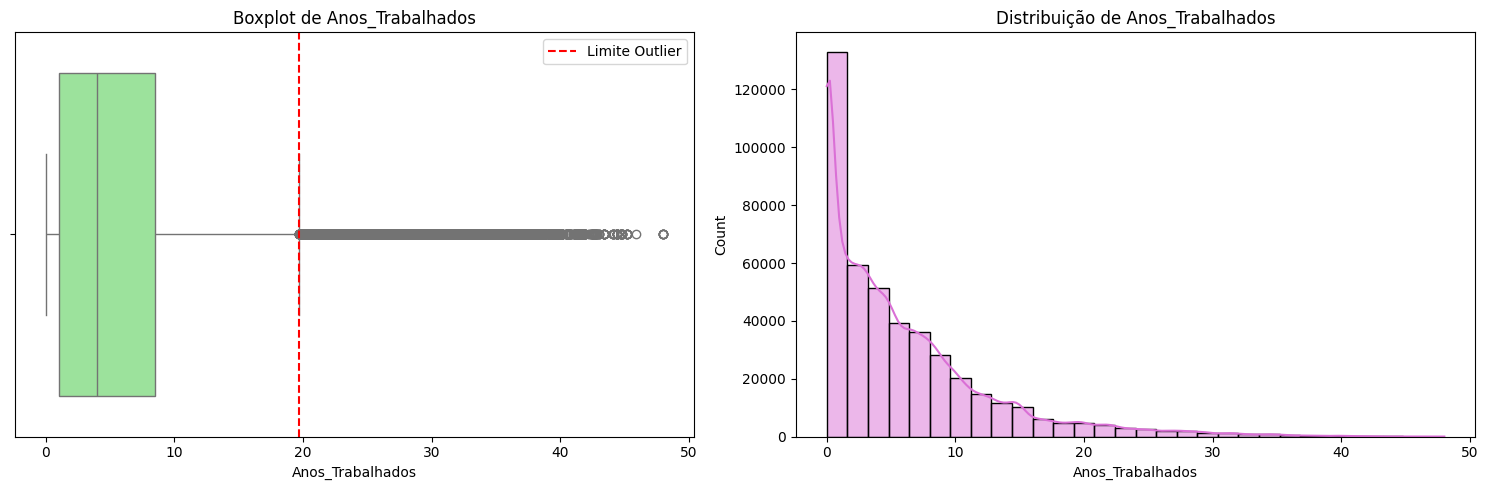

In [52]:
# Criando a coluna Anos_Trabalhados com base em DAYS_EMPLOYED
# Valores positivos em DAYS_EMPLOYED (como 365243) indicam desemprego, então definimos como 0.
df_excel['Anos_Trabalhados'] = df_excel['DAYS_EMPLOYED'].apply(lambda x: -x / 365.25 if x < 0 else 0)

col = 'Anos_Trabalhados'
Q1 = df_excel[col].quantile(0.25)
Q3 = df_excel[col].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

outliers = df_excel[df_excel[col] > limite_superior]
print(f"--- {col} ---")
print(f"Limite superior para outlier: {limite_superior:.2f} anos")
print(f"Quantidade de registros acima do limite: {outliers.shape[0]} ({outliers.shape[0]/df_excel.shape[0]*100:.2f}%)")
print(f"Máximo de anos trabalhados registrado: {df_excel[col].max():.2f} anos")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(ax=axes[0], x=df_excel[col], color='lightgreen')
axes[0].set_title(f'Boxplot de {col}')
axes[0].axvline(limite_superior, color='red', linestyle='--', label='Limite Outlier')
axes[0].legend()

sns.histplot(ax=axes[1], x=df_excel[col], bins=30, kde=True, color='orchid')
axes[1].set_title(f'Distribuição de {col}')
plt.tight_layout()
plt.show()

*   Análise da Idade

--- Idade ---
Limite inferior para outlier: 5.64 anos
Limite superior para outlier: 81.97 anos
Quantidade de registros fora dos limites: 0 (0.00%)
Idade mínima registrada: 20.50 anos
Idade máxima registrada: 69.00 anos


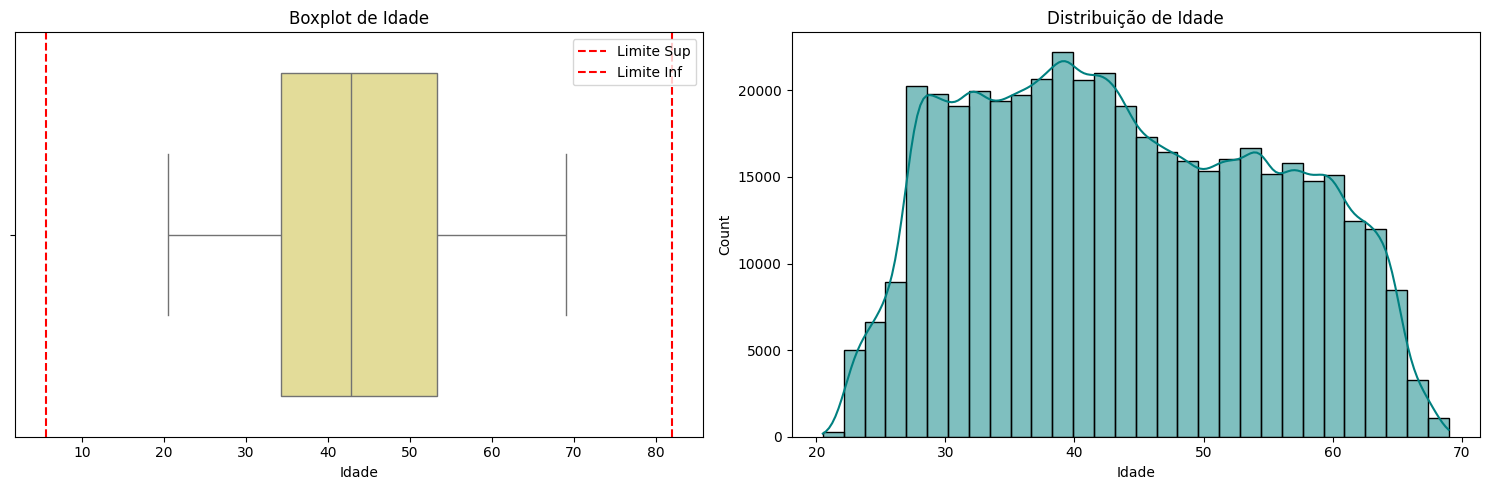

In [39]:
col = 'Idade'
Q1 = df_excel[col].quantile(0.25)
Q3 = df_excel[col].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df_excel[(df_excel[col] < limite_inferior) | (df_excel[col] > limite_superior)]

print(f"--- {col} ---")
print(f"Limite inferior para outlier: {limite_inferior:.2f} anos")
print(f"Limite superior para outlier: {limite_superior:.2f} anos")
print(f"Quantidade de registros fora dos limites: {outliers.shape[0]} ({outliers.shape[0]/df_excel.shape[0]*100:.2f}%)")
print(f"Idade mínima registrada: {df_excel[col].min():.2f} anos")
print(f"Idade máxima registrada: {df_excel[col].max():.2f} anos")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(ax=axes[0], x=df_excel[col], color='khaki')
axes[0].set_title(f'Boxplot de {col}')
axes[0].axvline(limite_superior, color='red', linestyle='--', label='Limite Sup')
axes[0].axvline(limite_inferior, color='red', linestyle='--', label='Limite Inf')
axes[0].legend()

sns.histplot(ax=axes[1], x=df_excel[col], bins=30, kde=True, color='teal')
axes[1].set_title(f'Distribuição de {col}')
plt.tight_layout()
plt.show()

```markdown
*   Análise da Quantidade de Membros da Família
```

--- CNT_FAM_MEMBERS ---
Limite inferior para outlier: 0.50
Limite superior para outlier: 4.50
Quantidade de registros fora dos limites: 5689 (1.30%)
Mínimo de membros familiar registrado: 1
Máximo de membros familiar registrado: 20


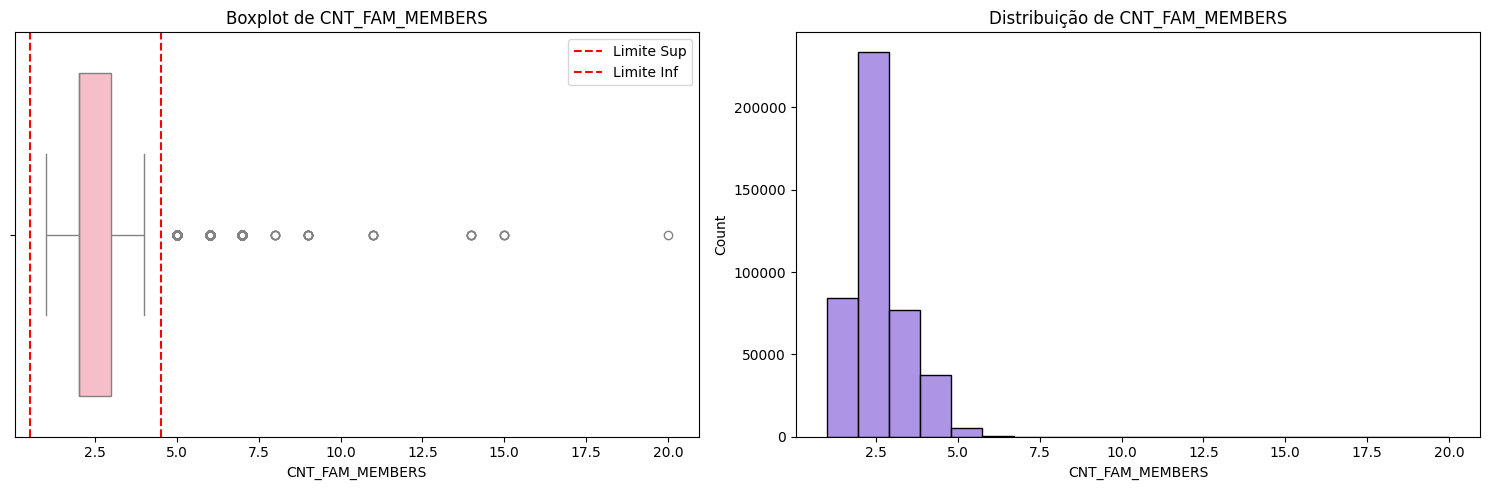

In [40]:
col = 'CNT_FAM_MEMBERS'
Q1 = df_excel[col].quantile(0.25)
Q3 = df_excel[col].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df_excel[(df_excel[col] < limite_inferior) | (df_excel[col] > limite_superior)]

print(f"--- {col} ---")
print(f"Limite inferior para outlier: {limite_inferior:.2f}")
print(f"Limite superior para outlier: {limite_superior:.2f}")
print(f"Quantidade de registros fora dos limites: {outliers.shape[0]} ({outliers.shape[0]/df_excel.shape[0]*100:.2f}%)")
print(f"Mínimo de membros familiar registrado: {df_excel[col].min():.0f}")
print(f"Máximo de membros familiar registrado: {df_excel[col].max():.0f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(ax=axes[0], x=df_excel[col], color='lightpink')
axes[0].set_title(f'Boxplot de {col}')
axes[0].axvline(limite_superior, color='red', linestyle='--', label='Limite Sup')
axes[0].axvline(limite_inferior, color='red', linestyle='--', label='Limite Inf')
axes[0].legend()

sns.histplot(ax=axes[1], x=df_excel[col], bins=20, kde=False, color='mediumpurple')
axes[1].set_title(f'Distribuição de {col}')
plt.tight_layout()
plt.show()

Tratameto dos outliers dos membros da família

=== ANTES DO TRATAMENTO ===
CNT_FAM_MEMBERS
20.0        1
15.0        3
14.0        4
11.0        5
9.0         9
8.0         4
7.0       124
6.0       459
5.0      5080
4.0     37350
Name: count, dtype: int64

=== DEPOIS DO TRATAMENTO ===
CNT_FAM_MEMBERS_TRATADO
5.0      5689
4.0     37350
3.0     77121
2.0    233870
1.0     84480
Name: count, dtype: int64


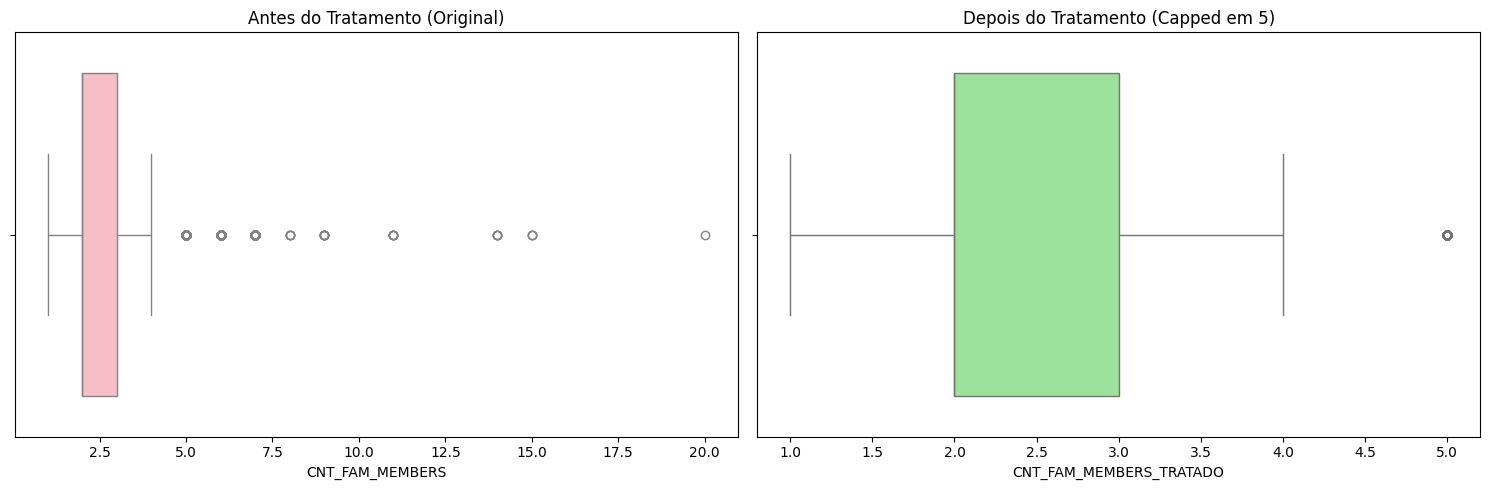

In [41]:
limite_capping = 5

df_excel['CNT_FAM_MEMBERS_TRATADO'] = df_excel['CNT_FAM_MEMBERS'].clip(upper=limite_capping)
if 'df' in globals():
    df['CNT_FAM_MEMBERS_TRATADO'] = df['CNT_FAM_MEMBERS'].clip(upper=limite_capping)

print("=== ANTES DO TRATAMENTO ===")
print(df_excel['CNT_FAM_MEMBERS'].value_counts().sort_index(ascending=False).head(10))

print("\n=== DEPOIS DO TRATAMENTO ===")
print(df_excel['CNT_FAM_MEMBERS_TRATADO'].value_counts().sort_index(ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(ax=axes[0], x=df_excel['CNT_FAM_MEMBERS'], color='lightpink')
axes[0].set_title('Antes do Tratamento (Original)')

sns.boxplot(ax=axes[1], x=df_excel['CNT_FAM_MEMBERS_TRATADO'], color='lightgreen')
axes[1].set_title('Depois do Tratamento (Capped em 5)')

plt.tight_layout()
plt.show()

##**1.2 Examinando a estrutura do arquivo "credit_record.csv"**

O arquivo possui 3 colunas e 1048575 linhas.

Para melhor entendimento, colocamos o significado em português de cada colunas:
- ID - Código do cliente
- MONTHS_BALANCE - Qtd de meses do balanço em relação ao atual
- STATUS - Situação do pagamento do cliente naquele mês.

In [42]:
df_excel2 = pd.read_csv('credit_record.csv', sep=",")

In [43]:
df_excel2.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [44]:
df_excel2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


In [45]:
df_excel2.shape

(1048575, 3)

In [46]:
df_excel2['ID'].nunique()

45985

In [47]:
df_excel2.describe()

,ID,MONTHS_BALANCE
count,1.048575e+06,1.048575e+06
mean,5.068286e+06,-1.913700e+01
std,4.615058e+04,1.402350e+01
min,5.001711e+06,-6.000000e+01
25%,5.023644e+06,-2.900000e+01
50%,5.062104e+06,-1.700000e+01
75%,5.113856e+06,-7.000000e+00
max,5.150487e+06,0.000000e+00


**Análise da coluna Status**

Verificamos que a coluna Status possui as seguintes categorias e sua interpretação:
- C: Pago (dentro do prazo).
- X: Sem empréstimo ou transações no mês.
- 0: 1-29 dias de atraso.
- 1: 30-59 dias de atraso.
- 2: 60-89 dias de atraso.
- 3: 90-119 dias de atraso.
- 4: 120-149 dias de atraso.
- 5: Mais de 150 dias de atraso

In [48]:
print("Valores na coluna STATUS:")
distribuicao_status = df_excel2['STATUS'].value_counts()
display(distribuicao_status)

Valores na coluna STATUS:


,count
STATUS,
C,442031
0,383120
X,209230
1,11090
5,1693
2,868
3,320
4,223


In [49]:
print("\nPorcentagem de cada status:")
display(df_excel2['STATUS'].value_counts(normalize=True) * 100)


Porcentagem de cada status:


,proportion
STATUS,
C,42.155401
0,36.537205
X,19.953747
1,1.057626
5,0.161457
2,0.082779
3,0.030518
4,0.021267


**Análise da coluna MONTHS_BALANCE**

Verificamos que a coluna MONTHS_BALANC possui resultados que variam de 0 a -60, o que significa:
- 0: O mês atual (mês mais recente registrado).
- -1: Um mês atrás.
- -2: Dois meses atrás.
...
- -60: 60 meses atrás (5 anos de histórico).

In [50]:
valores_unicos = sorted(df_excel2['MONTHS_BALANCE'].unique(), reverse=True)
print(valores_unicos)

[np.int64(0), np.int64(-1), np.int64(-2), np.int64(-3), np.int64(-4), np.int64(-5), np.int64(-6), np.int64(-7), np.int64(-8), np.int64(-9), np.int64(-10), np.int64(-11), np.int64(-12), np.int64(-13), np.int64(-14), np.int64(-15), np.int64(-16), np.int64(-17), np.int64(-18), np.int64(-19), np.int64(-20), np.int64(-21), np.int64(-22), np.int64(-23), np.int64(-24), np.int64(-25), np.int64(-26), np.int64(-27), np.int64(-28), np.int64(-29), np.int64(-30), np.int64(-31), np.int64(-32), np.int64(-33), np.int64(-34), np.int64(-35), np.int64(-36), np.int64(-37), np.int64(-38), np.int64(-39), np.int64(-40), np.int64(-41), np.int64(-42), np.int64(-43), np.int64(-44), np.int64(-45), np.int64(-46), np.int64(-47), np.int64(-48), np.int64(-49), np.int64(-50), np.int64(-51), np.int64(-52), np.int64(-53), np.int64(-54), np.int64(-55), np.int64(-56), np.int64(-57), np.int64(-58), np.int64(-59), np.int64(-60)]


In [55]:
# céluda de encerramento do Notebook 01
from pathlib import Path

# 1. Definir o caminho da pasta de dados processados no Google Drive
PROCESSED_DIR = Path('/content/drive/MyDrive/Tech_Challenge_Fase_2/data/processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# 2. Salvar ambos os DataFrames tratados
OUTPUT_PATH_APP = PROCESSED_DIR / 'application_record_tratado.parquet'
OUTPUT_PATH_CREDIT = PROCESSED_DIR / 'credit_record_tratado.parquet'

df_excel.to_parquet(OUTPUT_PATH_APP, index=False)
df_excel2.to_parquet(OUTPUT_PATH_CREDIT, index=False)

print(f"✅ Base de cadastros salva em: {OUTPUT_PATH_APP}")
print(f"✅ Base de créditos salva em: {OUTPUT_PATH_CREDIT}")

✅ Base de cadastros salva em: /content/drive/MyDrive/Tech_Challenge_Fase_2/data/processed/application_record_tratado.parquet
✅ Base de créditos salva em: /content/drive/MyDrive/Tech_Challenge_Fase_2/data/processed/credit_record_tratado.parquet
